In [2]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne

# Notebook is inside: project_root/notebooks/
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print("Notebook dir:", NOTEBOOK_DIR)
print("Project root:", PROJECT_ROOT)

from src.config import (
    DATA_ROOT,
    TARGET_CHANNELS,
    L_FREQ,
    H_FREQ,
    NOTCH_FREQ,
    WINDOW_SIZE_SEC,
    STRIDE_SEC,
    OVERLAP_LABEL_THRESHOLD,
)

from src.summary_parser import parse_patient_summary
from src.edf_loader import load_and_prepare_edf
from src.windowing import create_windows
from src.channel_utils import normalize_channel_name, build_channel_index_map

Notebook dir: /Users/koushik/projects/eeg-seizure-detection-brain-signal-analysis/notebooks
Project root: /Users/koushik/projects/eeg-seizure-detection-brain-signal-analysis


In [3]:
patient_id = "chb01"
edf_name = "chb01_15.edf"

patient_dir = DATA_ROOT / patient_id
summary_file = patient_dir / f"{patient_id}-summary.txt"
edf_path = patient_dir / edf_name

print("Patient dir exists:", patient_dir.exists())
print("Summary file exists:", summary_file.exists())
print("EDF file exists:", edf_path.exists())
print("EDF path:", edf_path)

Patient dir exists: True
Summary file exists: True
EDF file exists: True
EDF path: /Users/koushik/projects/eeg-seizure-detection-brain-signal-analysis/data/raw/chb01/chb01_15.edf


In [4]:
seizure_map = parse_patient_summary(summary_file)

print("Total files parsed from summary:", len(seizure_map))
print(f"Intervals for {edf_name}:", seizure_map.get(edf_name, []))

Total files parsed from summary: 42
Intervals for chb01_15.edf: [(1732, 1772)]


In [5]:
raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)

print("Raw shape:", raw.get_data().shape)
print("Sampling frequency:", raw.info["sfreq"])

print("\nOriginal channel names:")
print(raw.ch_names)

normalized_names = [normalize_channel_name(ch) for ch in raw.ch_names]

print("\nNormalized channel names:")
print(normalized_names)

Raw shape: (23, 921600)
Sampling frequency: 256.0

Original channel names:
['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8-0', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']

Normalized channel names:
['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2', 'FZ-CZ', 'CZ-PZ', 'P7-T7', 'T7-FT9', 'FT9-FT10', 'FT10-T8', 'T8-P8-1']


/var/folders/8g/ttg2t0td2blcgq4cm80ph_b80000gn/T/ipykernel_6761/194796379.py:1: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


In [6]:
ordered_idx = build_channel_index_map(raw.ch_names, TARGET_CHANNELS)
ordered_names = [normalized_names[i] for i in ordered_idx]

print("Target channels:")
print(TARGET_CHANNELS)

print("\nMapped channel order from EDF:")
print(ordered_names)

assert ordered_names == TARGET_CHANNELS, "Channel order mismatch"
print("\nChannel mapping verification passed.")

Target channels:
['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2', 'FZ-CZ', 'CZ-PZ']

Mapped channel order from EDF:
['FP1-F7', 'F7-T7', 'T7-P7', 'P7-O1', 'FP1-F3', 'F3-C3', 'C3-P3', 'P3-O1', 'FP2-F4', 'F4-C4', 'C4-P4', 'P4-O2', 'FP2-F8', 'F8-T8', 'T8-P8', 'P8-O2', 'FZ-CZ', 'CZ-PZ']

Channel mapping verification passed.


In [7]:
data, sfreq = load_and_prepare_edf(
    file_path=edf_path,
    target_channels=TARGET_CHANNELS,
    l_freq=L_FREQ,
    h_freq=H_FREQ,
    notch_freq=NOTCH_FREQ
)

print("Prepared data shape:", data.shape)
print("Prepared data dtype:", data.dtype)
print("Sampling frequency:", sfreq)

assert data.ndim == 2, "Expected 2D array: (channels, samples)"
assert data.shape[0] == len(TARGET_CHANNELS), "Wrong number of channels"
print("EDF loading + filtering + channel selection passed.")

/Users/koushik/projects/eeg-seizure-detection-brain-signal-analysis/src/edf_loader.py:15: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)


Prepared data shape: (18, 921600)
Prepared data dtype: float32
Sampling frequency: 256.0
EDF loading + filtering + channel selection passed.


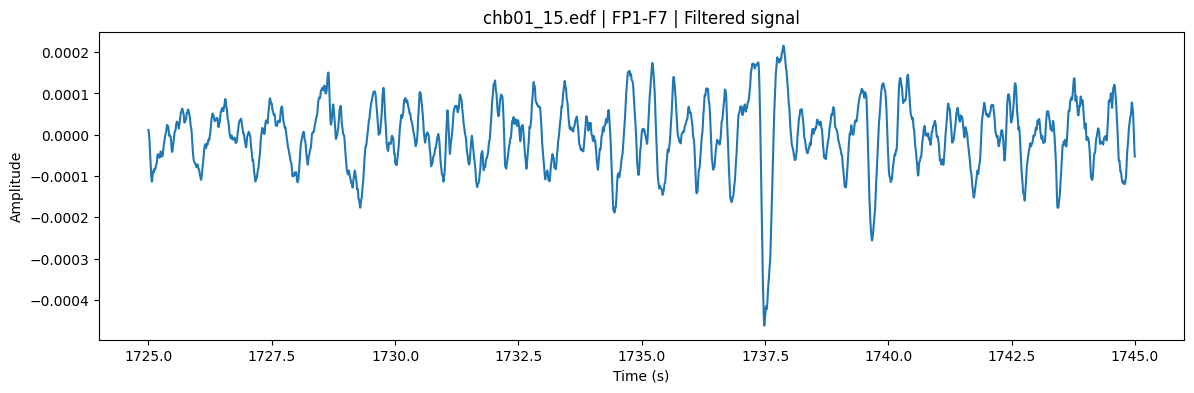

In [8]:
channel_idx = 0
start_sec = 1725
end_sec = 1745

start_idx = int(start_sec * sfreq)
end_idx = int(end_sec * sfreq)

times = np.arange(start_idx, end_idx) / sfreq

plt.figure(figsize=(14, 4))
plt.plot(times, data[channel_idx, start_idx:end_idx])
plt.title(f"{edf_name} | {TARGET_CHANNELS[channel_idx]} | Filtered signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

In [9]:
seizure_intervals = seizure_map.get(edf_name, [])

X, y, meta = create_windows(
    data=data,
    sfreq=sfreq,
    seizure_intervals=seizure_intervals,
    window_size_sec=WINDOW_SIZE_SEC,
    stride_sec=STRIDE_SEC,
    overlap_threshold=OVERLAP_LABEL_THRESHOLD
)

print("Window tensor shape:", X.shape)
print("Label vector shape:", y.shape)
print("Total windows:", len(y))
print("Positive windows:", int(y.sum()))
print("Negative windows:", len(y) - int(y.sum()))
print("First 20 labels:", y[:20])

assert X.ndim == 3, "Expected 3D window tensor"
assert X.shape[1] == len(TARGET_CHANNELS), "Channel count mismatch in windows"
assert len(X) == len(y) == len(meta), "Mismatch among X, y, meta"
print("Windowing + labeling passed.")

Window tensor shape: (1798, 18, 1280)
Label vector shape: (1798,)
Total windows: 1798
Positive windows: 22
Negative windows: 1776
First 20 labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Windowing + labeling passed.


In [10]:
meta_df = pd.DataFrame(meta)
meta_df["label"] = y

print(meta_df.head())
print("\nPositive label count:")
print(meta_df["label"].value_counts())

   start_sec  end_sec  label
0        0.0      5.0      0
1        2.0      7.0      0
2        4.0      9.0      0
3        6.0     11.0      0
4        8.0     13.0      0

Positive label count:
label
0    1776
1      22
Name: count, dtype: int64


In [11]:
if len(seizure_intervals) > 0:
    sz_start, sz_end = seizure_intervals[0]
    print("Seizure interval:", sz_start, sz_end)

    around_seizure = meta_df[
        (meta_df["end_sec"] >= sz_start - 10) &
        (meta_df["start_sec"] <= sz_end + 10)
    ].copy()

    display(around_seizure[["start_sec", "end_sec", "label"]].head(40))
else:
    print("No seizure intervals found for this file.")

Seizure interval: 1732 1772


,start_sec,end_sec,label
859,1718.0,1723.0,0
860,1720.0,1725.0,0
861,1722.0,1727.0,0
862,1724.0,1729.0,0
863,1726.0,1731.0,0
864,1728.0,1733.0,1
865,1730.0,1735.0,1
866,1732.0,1737.0,1
867,1734.0,1739.0,1
868,1736.0,1741.0,1


In [12]:
positive_indices = np.where(y == 1)[0]
negative_indices = np.where(y == 0)[0]

print("Positive window count:", len(positive_indices))
print("Negative window count:", len(negative_indices))

Positive window count: 22
Negative window count: 1776


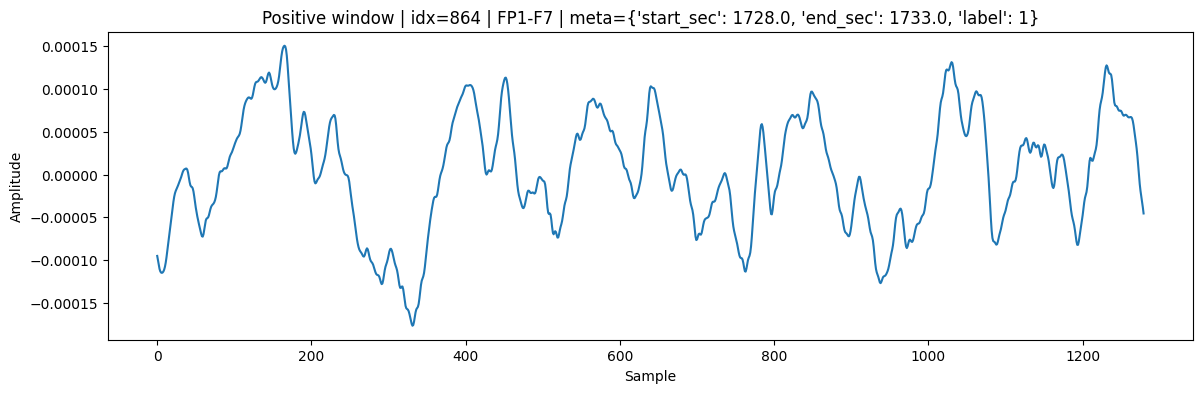

In [13]:
if len(positive_indices) > 0:
    idx = positive_indices[0]
    plt.figure(figsize=(14, 4))
    plt.plot(X[idx][0])
    plt.title(f"Positive window | idx={idx} | {TARGET_CHANNELS[0]} | meta={meta[idx]}")
    plt.xlabel("Sample")
    plt.ylabel("Amplitude")
    plt.show()
else:
    print("No positive window found.")

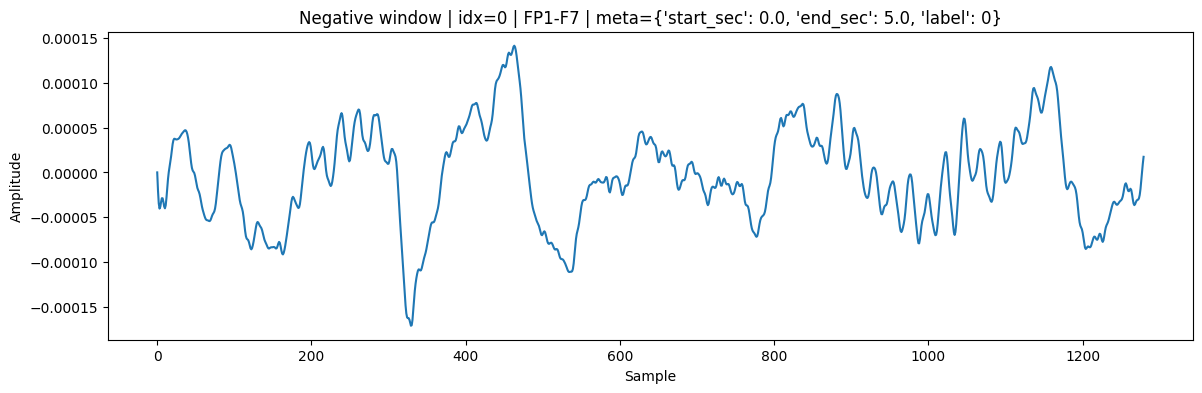

In [14]:
if len(negative_indices) > 0:
    idx = negative_indices[0]
    plt.figure(figsize=(14, 4))
    plt.plot(X[idx][0])
    plt.title(f"Negative window | idx={idx} | {TARGET_CHANNELS[0]} | meta={meta[idx]}")
    plt.xlabel("Sample")
    plt.ylabel("Amplitude")
    plt.show()
else:
    print("No negative window found.")

In [15]:
print("========== VERIFICATION SUMMARY ==========")
print("EDF file:", edf_name)
print("Sampling frequency:", sfreq)
print("Prepared data shape:", data.shape)
print("Window tensor shape:", X.shape)
print("Labels shape:", y.shape)
print("Seizure intervals:", seizure_intervals)
print("Positive windows:", int(y.sum()))
print("Negative windows:", len(y) - int(y.sum()))
print("Unique labels:", np.unique(y))
print("==========================================")

========== VERIFICATION SUMMARY ==========
EDF file: chb01_15.edf
Sampling frequency: 256.0
Prepared data shape: (18, 921600)
Window tensor shape: (1798, 18, 1280)
Labels shape: (1798,)
Seizure intervals: [(1732, 1772)]
Positive windows: 22
Negative windows: 1776
Unique labels: [0 1]


In [16]:
patient_id = "chb01"
edf_name = "chb01_01.edf"

patient_dir = DATA_ROOT / patient_id
summary_file = patient_dir / f"{patient_id}-summary.txt"
edf_path = patient_dir / edf_name

seizure_map = parse_patient_summary(summary_file)
seizure_intervals = seizure_map.get(edf_name, [])

data, sfreq = load_and_prepare_edf(
    file_path=edf_path,
    target_channels=TARGET_CHANNELS,
    l_freq=L_FREQ,
    h_freq=H_FREQ,
    notch_freq=NOTCH_FREQ
)

X, y, meta = create_windows(
    data=data,
    sfreq=sfreq,
    seizure_intervals=seizure_intervals,
    window_size_sec=WINDOW_SIZE_SEC,
    stride_sec=STRIDE_SEC,
    overlap_threshold=OVERLAP_LABEL_THRESHOLD
)

print("Seizure intervals:", seizure_intervals)
print("Unique labels:", np.unique(y))
print("Positive windows:", int(y.sum()))
print("Negative windows:", len(y) - int(y.sum()))

/Users/koushik/projects/eeg-seizure-detection-brain-signal-analysis/src/edf_loader.py:15: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file_path, preload=True, verbose=False)


Seizure intervals: []
Unique labels: [0]
Positive windows: 0
Negative windows: 1798
